# Simulated IRFs from True VAR Model

This code creates simulated time series data where the underlying process is a VAR model, in order to asses the accuracy of LPs & SPLs when the true process is follows a VAR structure. The underlying VAR model uses randomly generated coefficients and is of order $O$ with $V$ variables. Since all variables are ex-ante identical, only a shock to variable 1 will be considered and only the IRFs for the first three variables will be examined.

In [106]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

# import slp module
from slp.estimators import SmoothLocalProjections

In [107]:
# set parameters
q = 20 # number of periods for IRF
T = 100 # number of periods for simulated data
O = 4 # VAR order
V = 3 # number of variables in VAR

np.random.seed(3891) # set seed for reproducibility

In [108]:
# IRF plotting function
def plot_irf(data, title):
    varnames = data.columns
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(2, 3, i+1)
        plt.plot(data[varnames[i]])
        plt.title(f'var1 -> var{i+1}')
        plt.xlabel('Quarters')
        plt.ylabel('Response')
        plt.axhline(0, color='black', linestyle='dashed')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### Generating observed data

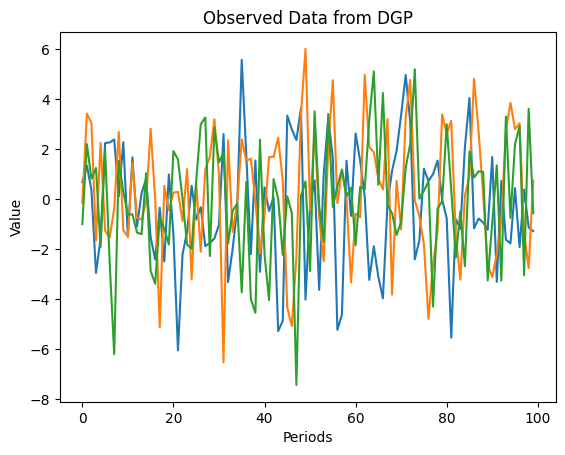

In [109]:
# simulate data from VAR process based on parameters and random coefficients
A = np.random.uniform(low = -0.25, high = 0.25, size=(O, V, V)) # coefficients restricted to prevent explosive processes

I = np.ones((O, 3)) # initial periods of data

observed_data = np.zeros((T+O, V))
for t in range(0, T+O):
    if t < O:
        observed_data[t] = I[t]
    else:
        for o in range(1, O+1):
            observed_data[t] += A[o-1] @ observed_data[t-o, :] + np.random.normal(size = V) # VAR process
observed_data = pd.DataFrame(observed_data, columns=[f'var{i}' for i in range(1, V+1)])

observed_data = observed_data.drop(index=range(O)) # drop initial periods of data
observed_data = observed_data.reset_index(drop = True)

# plot observed time series
plt.plot(observed_data)
plt.title("Observed Data from DGP")
plt.xlabel("Periods")
plt.ylabel("Value")
plt.show()

### Generating the true IRFs

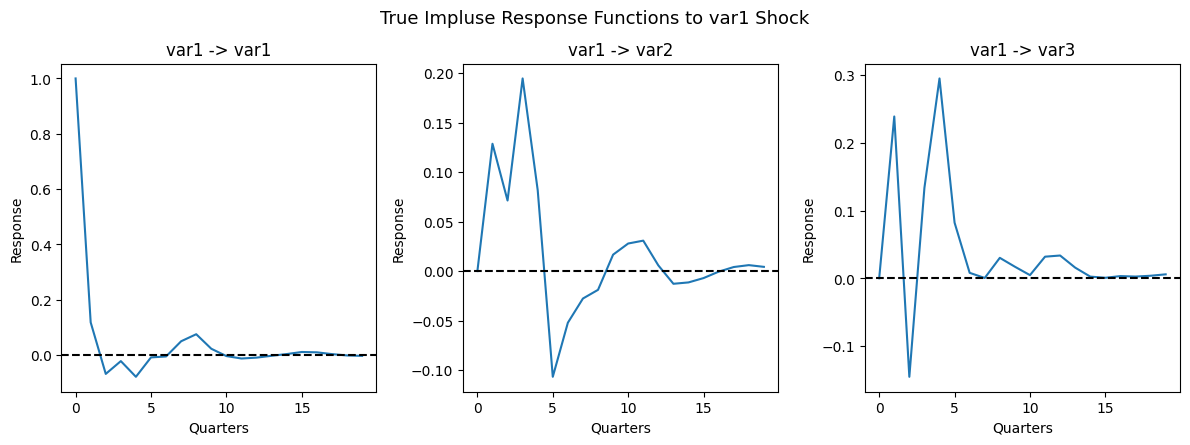

In [110]:
# true IRF from for a unit var1 shock
# this is the true IRF that the econometrician is trying to estimate from observed data
true_irf = np.zeros((q, V, V))

shock = np.zeros(V)
shock[0] = 1 # shock variable 1
irf = np.zeros((q, V))
for t in range(q):
    if t == 0:
        irf[t] = shock
    else:
        for o in range(1, O+1):
            if t-o >= 0:
                irf[t] += A[o-1] @ irf[t-o]
true_irf[:, 0, :] = irf 

true_irf = pd.DataFrame(true_irf.reshape(q, V*V), columns=[f'var{j}_shock{i}' for i in range(1, V+1) for j in range(1, V+1)])

# plot the true IRFs to a unit shock in variable 1
plot_irf(true_irf, 'True Impluse Response Functions to var1 Shock')

### Estimating the IRFs using VAR

AIC optimal lags: 4


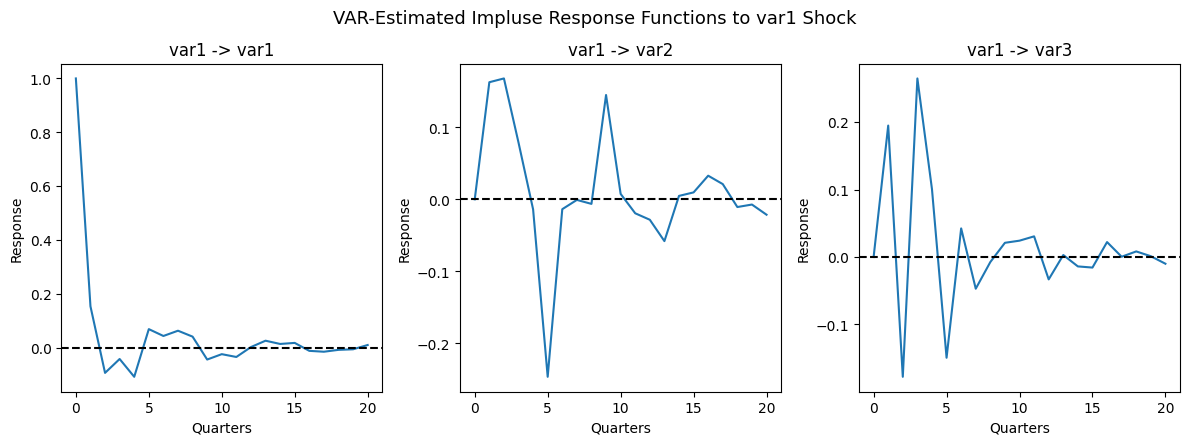

In [111]:
# VAR estimation of IRFs
model = VAR(observed_data)
results = model.fit(ic="aic")
irfs = results.irf(periods=q).irfs
var = pd.DataFrame(irfs[:,:,0])

print("AIC optimal lags:", model.select_order(maxlags=10).aic) # optimal lags from AIC - used for VAR, LP, and SLP estimation

plot_irf(var, 'VAR-Estimated Impluse Response Functions to var1 Shock')

### Estimating the IRFs using local projections

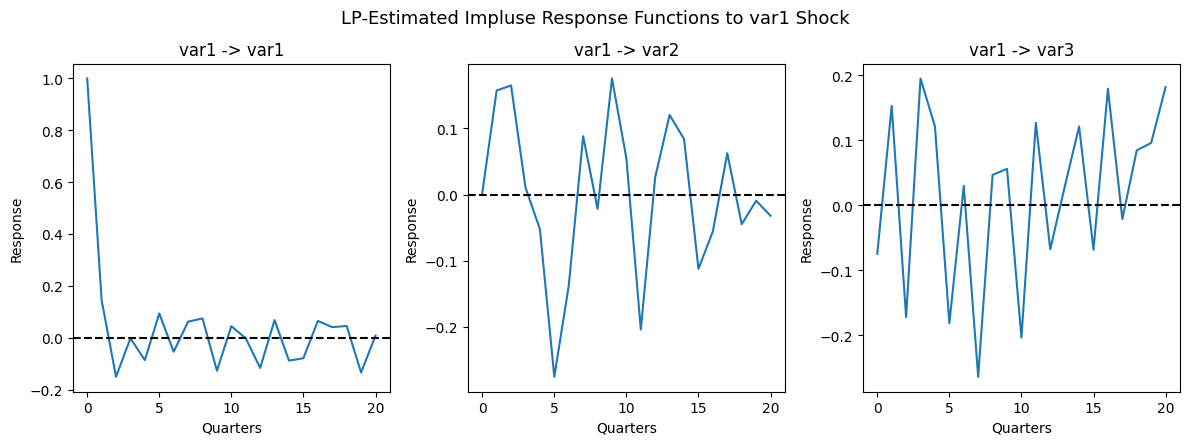

In [112]:
# estimating IRF using LPs on observed data
LP_model = SmoothLocalProjections(observed_data, "var1", None, True, 4, q)
LP = pd.DataFrame(LP_model.LP().beta)

plot_irf(LP, 'LP-Estimated Impluse Response Functions to var1 Shock')

### Estimating the IRFs using smooth local projections

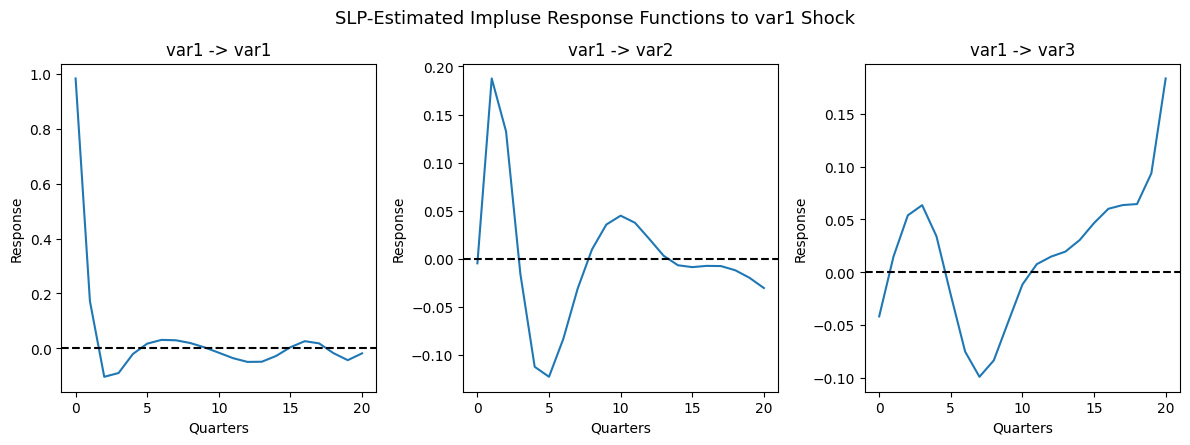

In [113]:
# estimating IRF using SLPs on observed data
SLP_model = SmoothLocalProjections(observed_data, "var1", None, True, 4, q)
SLP = pd.DataFrame(SLP_model.SLP().beta)

plot_irf(SLP, 'SLP-Estimated Impluse Response Functions to var1 Shock')

### Discussion